### BRADLEY ROWLAND KIBWANA
### P15/144964/2022


# Business Intelligence - Visualization

## Business Question: Analyzing Sales Performance Across Different Dimensions

### Business Context:
As a supermarket chain, we need to understand our sales performance across various dimensions to identify trends, opportunities, and areas for improvement. This analysis will help us make data-driven decisions about inventory management, marketing strategies, and store operations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


df = pd.read_csv('supermarket_sales - Sheet1.csv')


df['Date'] = pd.to_datetime(df['Date'])

# Creating additional date features
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

## 1. Dashboard - Sales Performance Overview

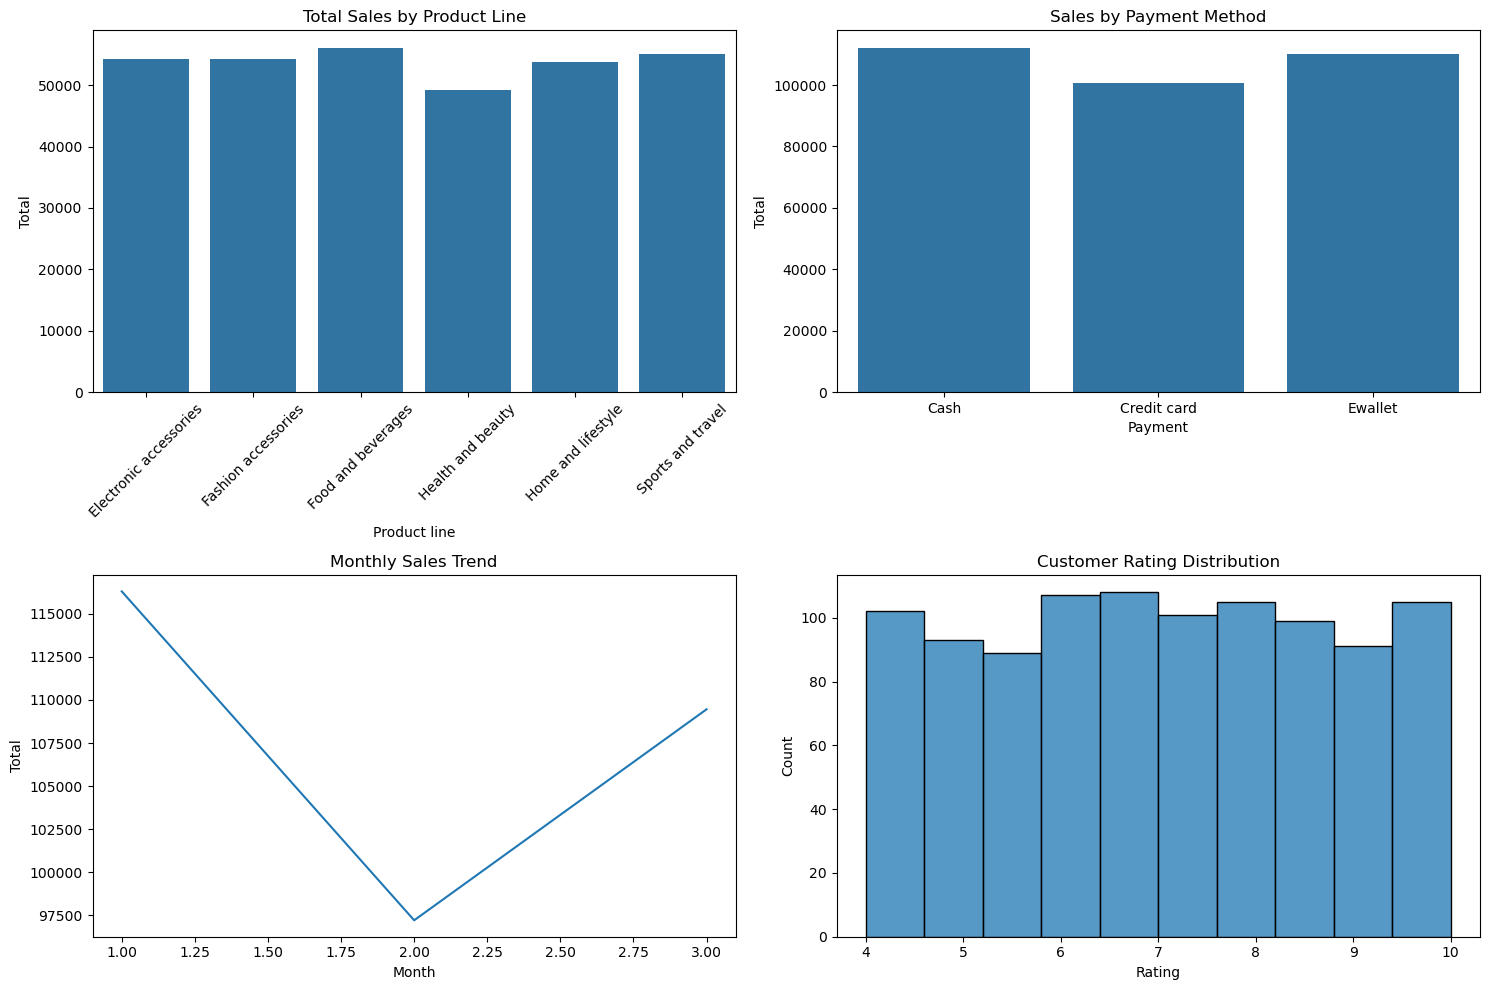

In [ ]:
# Creating a dashboard with multiple visualizations
plt.figure(figsize=(15, 10))

# Total Sales by Product Line
plt.subplot(2, 2, 1)
sns.barplot(data=df.groupby('Product line')['Total'].sum().reset_index(),
x='Product line',
y='Total')
plt.title('Total Sales by Product Line')
plt.xticks(rotation=45)

# Sales by Payment Method
plt.subplot(2, 2, 2)
sns.barplot(data=df.groupby('Payment')['Total'].sum().reset_index(),
x='Payment',
y='Total')
plt.title('Sales by Payment Method')

# Monthly Sales Trend
plt.subplot(2, 2, 3)
monthly_sales = df.groupby(['Year', 'Month'])['Total'].sum().reset_index()
sns.lineplot(data=monthly_sales, x='Month', y='Total')
plt.title('Monthly Sales Trend')

# Customer Rating Distribution
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Rating', bins=10)
plt.title('Customer Rating Distribution')

plt.tight_layout()
plt.show()

## 2. Heat Map - Sales Performance by Time and Product

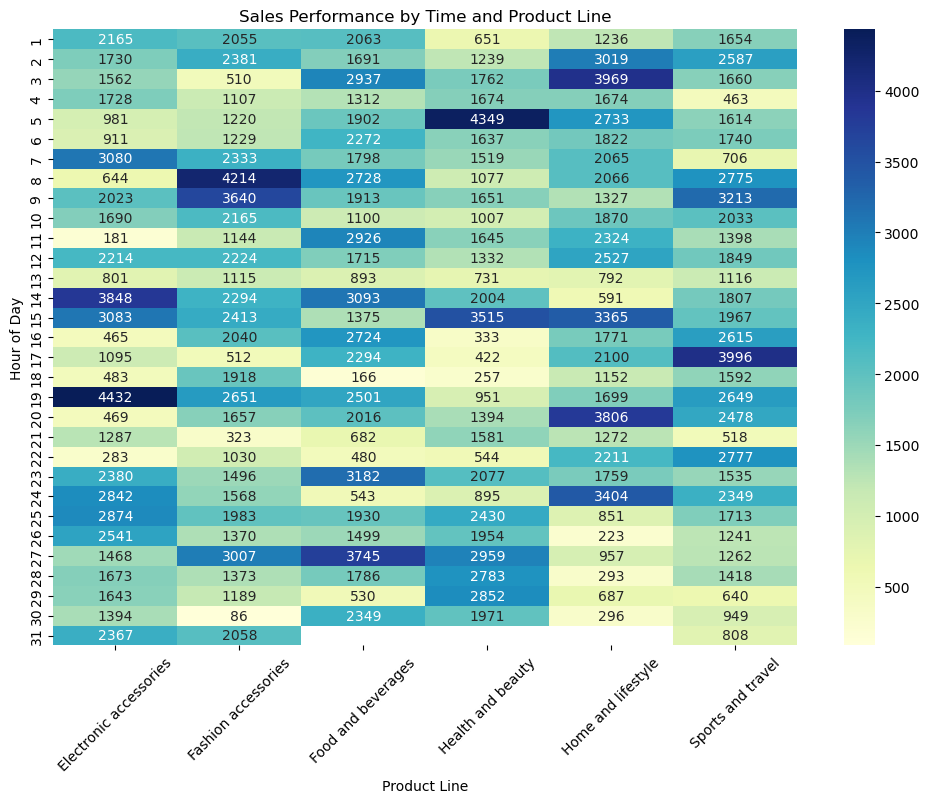

In [ ]:
# Creating a pivot table for heatmap
heatmap_data = df.pivot_table(index='Day',
columns='Product line',
values='Total',
aggfunc='sum')

# Plotting a  heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Sales Performance by Time and Product Line')
plt.xlabel('Product Line')
plt.ylabel('Hour of Day')
plt.xticks(rotation=45)
plt.show()

## 3. Fever Chart - Daily Sales Trend

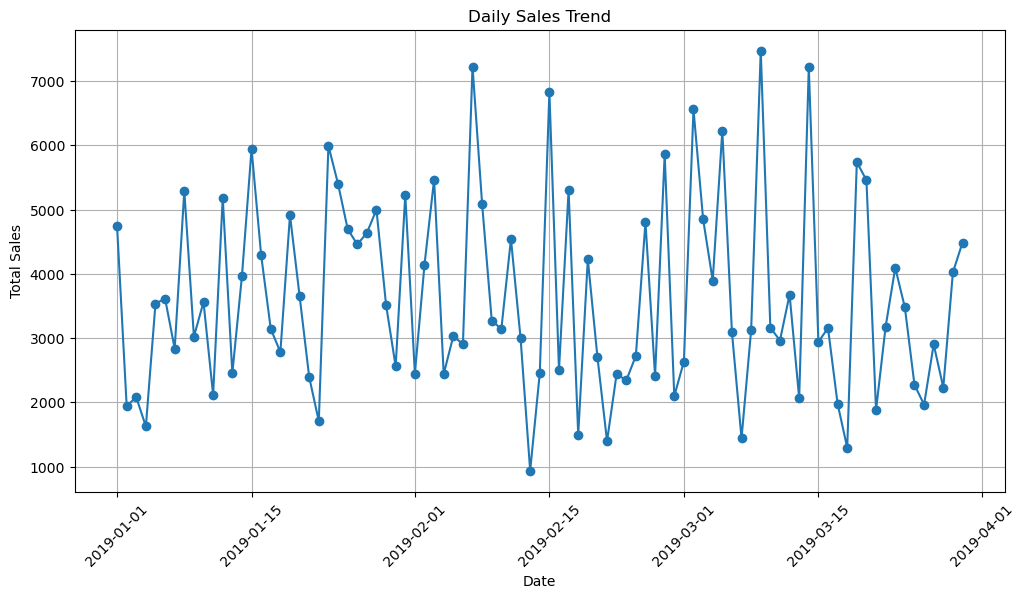

In [5]:
# Daily sales trend
daily_sales = df.groupby('Date')['Total'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Date'], daily_sales['Total'], marker='o')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## 4. Dial Gauge - Key Performance Indicators

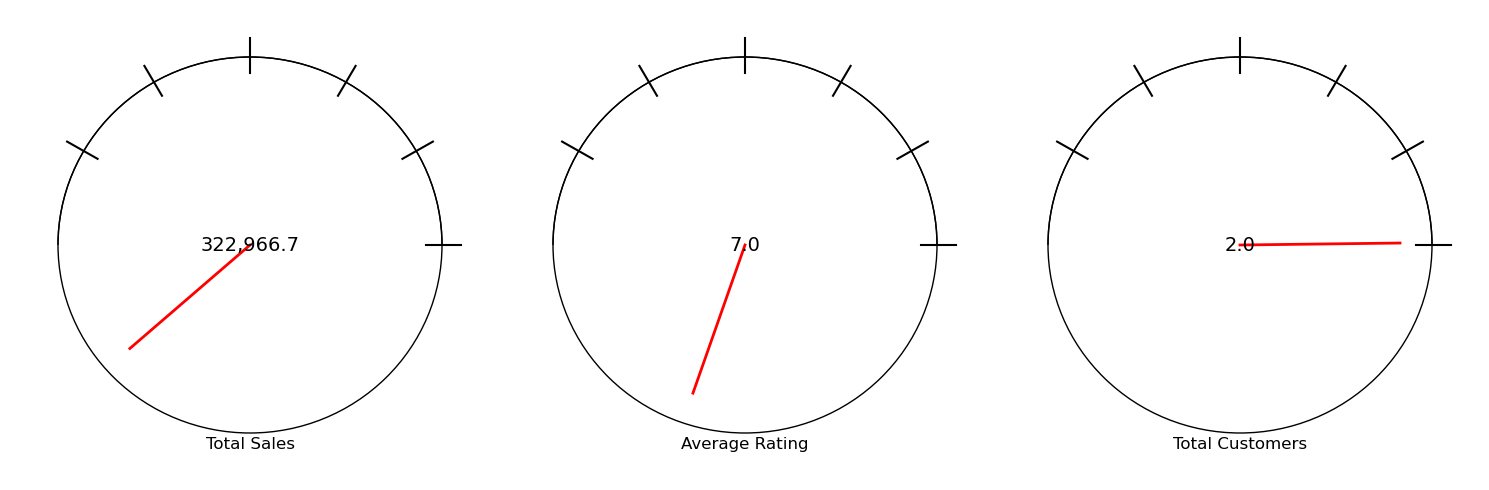

In [ ]:
import matplotlib.patches as patches
# Calculating KPIs
total_sales = df['Total'].sum()
average_rating = df['Rating'].mean()
total_customers = df['Customer type'].nunique()

# Creating a figure with multiple gauges
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Function to create gauge
def create_gauge(ax, value, max_value, title):
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axis('off')
    
    # Create outer circle
    circle = plt.Circle((0, 0), 1.2, fill=False, color='black')
    ax.add_patch(circle)
    
    # Create arc
    arc = patches.Arc((0, 0), 2.4, 2.4, theta1=0, theta2=180, color='black')
    ax.add_patch(arc)
    
    # Create ticks
    for i in range(6):
        angle = i * 30
        x = 1.1 * np.cos(np.radians(angle))
        y = 1.1 * np.sin(np.radians(angle))
        ax.plot([x, 1.2*x], [y, 1.2*y], 'k-')
    
    # Create pointer
    angle = (value / max_value) * 180
    x = 1.0 * np.cos(np.radians(angle))
    y = 1.0 * np.sin(np.radians(angle))
    ax.plot([0, x], [0, y], 'r-', linewidth=2)
    
    # Add value text
    ax.text(0, 0, f'{value:,.1f}', ha='center', va='center', fontsize=14)
    
    # Add title
    ax.text(0, -1.3, title, ha='center', fontsize=12)

# Sales Gauge
create_gauge(axes[0], total_sales, 100000, 'Total Sales')

# Rating Gauge
create_gauge(axes[1], average_rating, 5, 'Average Rating')

# Customers Gauge
create_gauge(axes[2], total_customers, 500, 'Total Customers')

plt.tight_layout()
plt.show()